This program is free software: you can redistribute it and/or modify
it under the terms of the GNU Lesser General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU Lesser General Public License for more details.

You should have received a copy of the GNU Lesser General Public License
along with this program.  If not, see <http://www.gnu.org/licenses/>.

___

- **Author:** Pau Manyer Fuertes
- **Email:** pau.manyer@bsc.es
- **Date:** July 2025
- **Institution:** Barcelona Supercomputing Center (BSC)
- **Department:** Computer Applications in Science and Engineering (CASE)
- **Research Group:** Nuclear Fusion  
___

This jupyter notebook file constitutes the testing script for solving using a CutFEM scheme the FIXED-boundary plasma boundary problem with NONLINEAR plasma current model.

The problem is solved using the developed module EQUILIPY. EQUILIPY solves using CutFEM the Grad-Shafranov nonlinear elliptic PDE modelling the equilibrium in an axisymmetrical plasma system. 

# DEFINE EQUILIBRIUM PROBLEM PARAMETERS

In [29]:
from _header import EQUILIPY_ROOT

from GradShafranovSolver import *

## CREATE GRAD-SHAFRANOV PROBLEM
Equilibrium = GradShafranovSolver()

## DECLARE SWITCHS:
##### GHOST PENALTY STABILISATION
Equilibrium.FIXED_BOUNDARY = True
Equilibrium.GhostStabilization = False
Equilibrium.PARALLEL = False

##### OUTPUT PLOTS IN RUNTIME
Equilibrium.plotelemsClas = False      # OUTPUT SWITCH FOR ELEMENTS CLASSIFICATION PLOTS AT EACH ITERATION
Equilibrium.plotPSI = True             # OUTPUT SWITCH FOR PSI SOLUTION PLOTS AT EACH ITERATION
##### OUTPUT FILES
Equilibrium.out_proparams = True       # OUTPUT SWITCH FOR SIMULATION PARAMETERS 
Equilibrium.out_boundaries = True
Equilibrium.out_elemsClas = True       # OUTPUT SWITCH FOR CLASSIFICATION OF MESH ELEMENTS
Equilibrium.out_plasmaLS = True        # OUTPUT SWITCH FOR PLASMA BOUNDARY LEVEL-SET FIELD VALUES
Equilibrium.out_plasmaBC = True        # OUTPUT SWITCH FOR PLASMA BOUNDARY CONDITION VALUES 
Equilibrium.out_plasmaapprox = True    # OUTPUT SWITCH FOR PLASMA BOUNDARY APPROXIMATION DATA 
Equilibrium.out_ghostfaces = True      # OUTPUT SWITCH FOR GHOST STABILISATION FACES DATA 
Equilibrium.out_quadratures = True
Equilibrium.out_elemsys = True         # OUTPUT SWITCH FOR ELEMENTAL MATRICES
##### OUTPUT PICKLING
Equilibrium.out_pickle = True          # OUTPUT SWITCH FOR SIMULATION DATA PYTHON PICKLE

# DEFINE NUMERICAL_TREATMENT PARAMETERS  
Equilibrium.dim = 2                    # PROBLEM SPATIAL DIMENSION
Equilibrium.QuadratureOrder2D = 8      # ORDER OF SURFACE NUMERICAL INTEGRATION QUADRATURES 
Equilibrium.QuadratureOrder1D = 5      # ORDER OF LENGTH NUMERICAL INTEGRATION QUADRATURES 
Equilibrium.ext_maxiter = 5            # EXTERNAL LOOP (PHI_B) MAXIMUM ITERATIONS
Equilibrium.ext_tol = 1.0e-3           # EXTERNAL LOOP (PHI_B) CONVERGENCE TOLERANCE
Equilibrium.int_maxiter = 10           # INTERNAL LOOP (PHI_NORM) MAXIMUM ITERATIONS
Equilibrium.int_tol = 1.0e-4           # INTERNAL LOOP (PHI_NORM) CONVERGENCE TOLERANCE
Equilibrium.tol_saddle = 0.1           # TOLERANCE FOR DISTANCE BETWEEN CONSECUTIVE ITERATION SADDLE POINTS (LETS PLASMA REGION CHANGE)
Equilibrium.beta = 1.0e6               # NITSCHE'S METHOD PENALTY PARAMETER
Equilibrium.Nconstrainedges = -1       # NUMBER OF PLAMA BOUNDARY APPROXIMATION EDGES ON WHICH CONSTRAIN BC
Equilibrium.zeta = 1.0e-2              # GHOST PENALTY PARAMETER
Equilibrium.R0_axis = 6.0              # MAGNETIC AXIS OPTIMIZATION ROUTINE INITIAL GUESS R COORDINATE
Equilibrium.Z0_axis = 1.0              # MAGNETIC AXIS OPTIMIZATION ROUTINE INITIAL GUESS Z COORDINATE
Equilibrium.R0_saddle = 5.0            # ACTIVE SADDLE POINT OPTIMIZATION ROUTINE INITIAL GUESS R COORDINATE
Equilibrium.Z0_saddle = -3.5           # ACTIVE SADDLE POINT OPTIMIZATION ROUTINE INITIAL GUESS Z COORDINATE
Equilibrium.opti_maxiter = 50          # CRITICAL POINTS OPTIMIZATION ALGORITHM MAXIMAL ITERATIONS NUMBER
Equilibrium.opti_tol = 1.0e-6          # CRITICAL POINTS OPTIMIZATION ALGORITHM SOLUTION TOLERANCE

Equilibrium.InitialiseParameters()
Equilibrium.InitialisePickleLists()

Equilipy --| Working directory: /home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY
Equilipy --| INITIALISE SIMULATION PARAMETERS...Done!


# SELECT COMPUTATIONAL MESH

In [36]:
###### LINEAR TRIANGULAR ELEMENT MESH
#MESH = 'TRI03-COARSE-LINEAR'
#MESH = 'TRI03-MEDIUM-LINEAR'
#MESH = 'TRI03-INTERMEDIATE-LINEAR'
#MESH = 'TRI03-FINE-LINEAR'
#MESH = 'TRI03-SUPERFINE-LINEAR'
#MESH = 'TRI03-MEGAFINE-LINEAR'
#MESH = 'TRI03-ULTRAFINE-LINEAR'

#MESH = 'QUA04-COARSE-LINEAR'
#MESH = 'QUA04-MEDIUM-LINEAR'
#MESH = 'QUA04-INTERMEDIATE-LINEAR'
#MESH = 'QUA04-FINE-LINEAR'
#MESH = 'QUA04-SUPERFINE-LINEAR'
#MESH = 'QUA04-MEGAFINE-LINEAR'
#MESH = 'QUA04-ULTRAFINE-LINEAR'

###### QUADRATIC TRIANGULAR ELEMENT MESH
#MESH = 'TRI06-COARSE-LINEAR'
#MESH = 'TRI06-MEDIUM-LINEAR'
#MESH = 'TRI06-INTERMEDIATE-LINEAR'
MESH = 'TRI06-FINE-LINEAR'
#MESH = 'TRI06-SUPERFINE-LINEAR'
#MESH = 'TRI06-MEGAFINE-LINEAR'
#MESH = 'TRI06-ULTRAFINE-LINEAR'

#MESH = 'QUA09-COARSE-LINEAR'
#MESH = 'QUA09-MEDIUM-LINEAR'
#MESH = 'QUA09-INTERMEDIATE-LINEAR'
#MESH = 'QUA09-FINE-LINEAR'
#MESH = 'QUA09-SUPERFINE-LINEAR'
#MESH = 'QUA09-MEGAFINE-LINEAR'
#MESH = 'QUA09-ULTRAFINE-LINEAR'

###### CUBIC TRIANGULAR ELEMENT MESH
#MESH = 'TRI10-COARSE-LINEAR'
#MESH = 'TRI10-MEDIUM-LINEAR'
#MESH = 'TRI10-INTERMEDIATE-LINEAR'
#MESH = 'TRI10-FINE-LINEAR'
#MESH = 'TRI10-SUPERFINE-LINEAR'
#MESH = 'TRI10-MEGAFINE-LINEAR'

###MESH = 'TRI10-ULTRAFINE-LINEAR'

Equilibrium.MESH = Mesh(MESH)

Equilipy --| Mesh folder: /home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY/MESHES/TRI06-FINE-LINEAR
Equilipy --| READ MESH FILES...Done!


# SELECT AND DEFINE TOKAMAK FIRST WALL MESH

Equilipy --| Mesh folder: /home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY/MESHES/TRI03-MEGAFINE-LINEAR-REDUCED
Equilipy --| READ MESH FILES...Done!


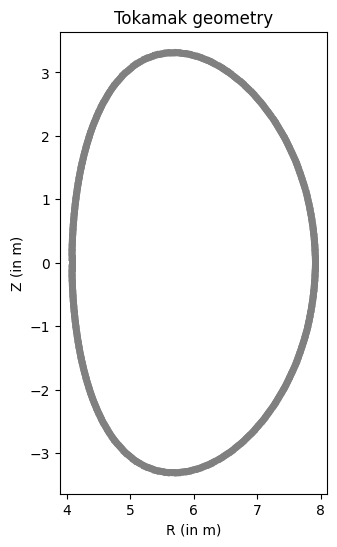

In [37]:
TOKmesh = Mesh('TRI03-MEGAFINE-LINEAR-REDUCED')
Equilibrium.TOKAMAK = Tokamak(WALL_MESH = TOKmesh)

Equilibrium.TOKAMAK.Plot()

# DEFINE INITIAL PLASMA BOUNDARY

PLASMA BOUNDARY PARAMETRISED USING LINEAR SOLUTION 0-LEVEL CONTOUR

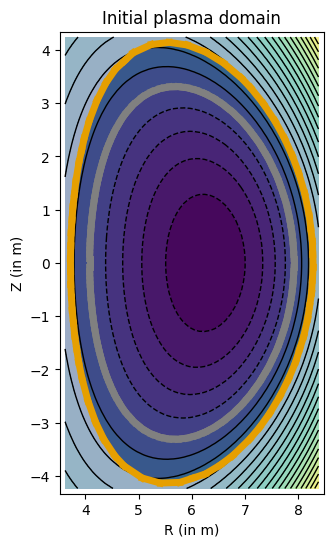

In [38]:
Equilibrium.initialPHI = InitialPlasmaBoundary(EQUILIBRIUM= Equilibrium,   
                                           GEOMETRY = 'LINEAR', # PREDEFINED MODEL
                                           R0 = 6.0,            # MEAN RADIUS          
                                           epsilon = 0.32,      # INVERSE ASPECT RATIO
                                           kappa = 1.7,         # ELONGATION
                                           delta = 0.33)        # TRIANGULARITY

Equilibrium.initialPHI.Plot()

# DEFINE INITIAL GUESS FOR PLASMA MAGNETIC FLUX

NONLINEAR PLASMA CURRENT MODEL ANALYTICAL SOLUTION WITH NOISE

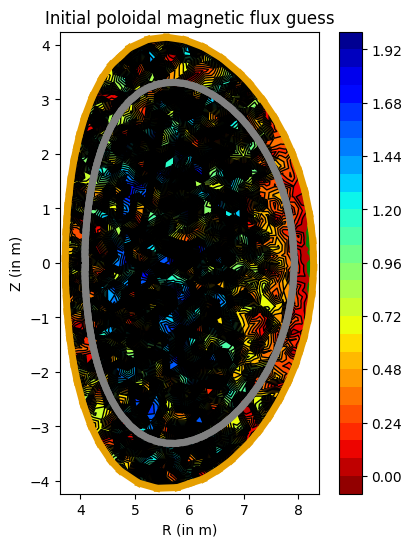

In [39]:
Equilibrium.initialPSI = InitialGuess(EQUILIBRIUM = Equilibrium,
                                  PSI_GUESS = 'NONLINEAR',  # PREDEFINED MODEL
                                  NOISE = True,             # WHITE NOISE 
                                  R0 = 6.0,                 # MEAN RADIUS
                                  A = 2.0)                  # NOISE AMPLITUDE         

Equilibrium.initialPSI.Plot()

# DEFINE PLASMA CURRENT MODEL

NONLINEAR PLASMA CURRENT MODEL

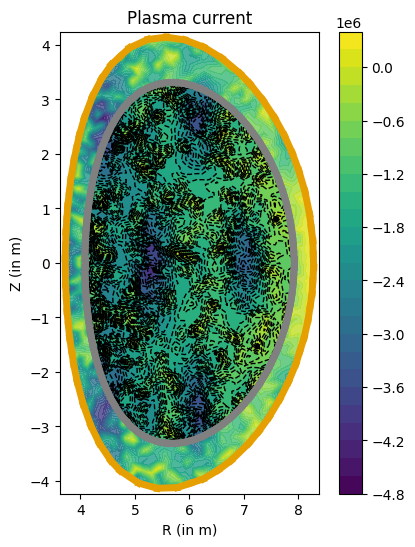

In [40]:
Equilibrium.PlasmaCurrent = CurrentModel(EQUILIBRIUM = Equilibrium,
                                     MODEL = 'NONLINEAR', # PREDEFINED MODEL
                                     R0 = 6.0)            # MEAN RADIUS

Equilibrium.PlasmaCurrent.Plot()

# RUN SIMULATION

Equilipy --| PERFORM DOMAIN DISCRETISATION...
Equilipy --| INITIALISATION TASKS...
Equilipy --|      -> INITIALISE LEVEL-SET...Done!
Equilipy --|      -> INITIALISE ELEMENTS...
Equilipy --|          · MESH ELEMENTS MEAN AREA = 0.040020540663371844 m^2
Equilipy --|          · MESH ELEMENTS MEAN LENGTH = 0.3025247897188234 m
Equilipy --|      Done!
Equilipy --|      -> IDENTIFY ELEMENTS MESH RELATION...Done!
Equilipy --|      -> COMPUTE STANDARD NUMERICAL INTEGRATION QUADRATURES...Done!
Equilipy --| Done!
Equilipy --|      -> CLASSIFY ELEMENTS...Done!
Equilipy --|      -> APPROXIMATE PLASMA BOUNDARY INTERFACE...Done!
Equilipy --|      -> COMPUTE PLASMA BOUNDARY APPROXIMATION QUADRATURES...Done!
Equilipy --|      -> ASSIGN PLASMA BOUNDARY CONSTRAINT VALUES...Done!
Equilipy --|      -> IDENTIFY GHOST FACES...Done!
Equilipy --|      -> COMPUTE GHOST FACES QUADRATURES...Done!
Equilipy --| Done!
Equilipy --| INITIALISE PSI...
Equilipy --|      -> INITIALISE PSI ARRAYS...Done!
Equilipy --|    

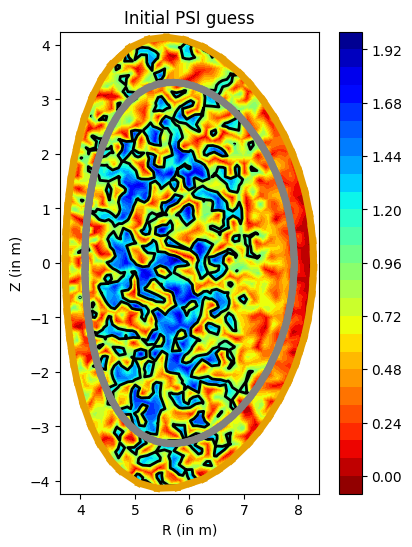

Equilipy --| START ITERATION...
Equilipy --| OUTER ITERATION = 1 , INNER ITERATION = 1
Equilipy --|      Total current =  -5296883.72017715
Equilipy --|      Integrate non-cut elements contributions...Done!
Equilipy --|      Integrate cut-elements subelements contributions...Done!
Equilipy --|      Integrate cut-elements interface contributions...Done!
Equilipy --|      Integrate ghost faces contributions...Done!
Equilipy --| Done!


/home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY/TESTs/../src/_plot.py:296: UserWarning: No contour levels were found within the data range.
  contour1 = ax.tricontour(self.MESH.X[:,0],self.MESH.X[:,1], field, levels=[psisep], colors = 'black',linewidths=2)


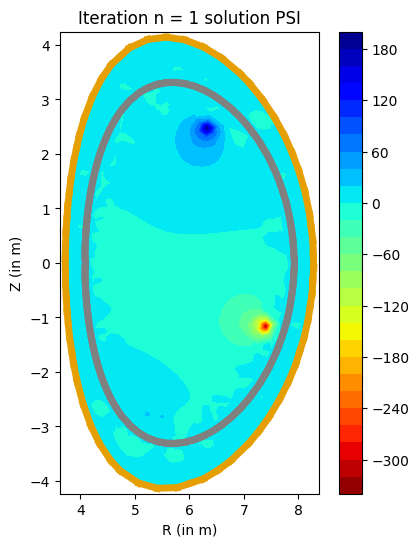

Equilipy --| Internal iteration =  1 , PSI_NORM residu =  1.0005332041444248
Equilipy --|  
Equilipy --| OUTER ITERATION = 1 , INNER ITERATION = 2
Equilipy --|      Total current =  4.0756610284151577e+124
Equilipy --|      Integrate non-cut elements contributions...Done!
Equilipy --|      Integrate cut-elements subelements contributions...Done!
Equilipy --|      Integrate cut-elements interface contributions...Done!
Equilipy --|      Integrate ghost faces contributions...Done!
Equilipy --| Done!


/home/pmanyerfuertes/.pyenv/versions/equilipy-env/lib/python3.12/site-packages/matplotlib/tri/triangulation.py:150: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)
/home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY/TESTs/../src/_plot.py:296: UserWarning: No contour levels were found within the data range.
  contour1 = ax.tricontour(self.MESH.X[:,0],self.MESH.X[:,1], field, levels=[psisep], colors = 'black',linewidths=2)


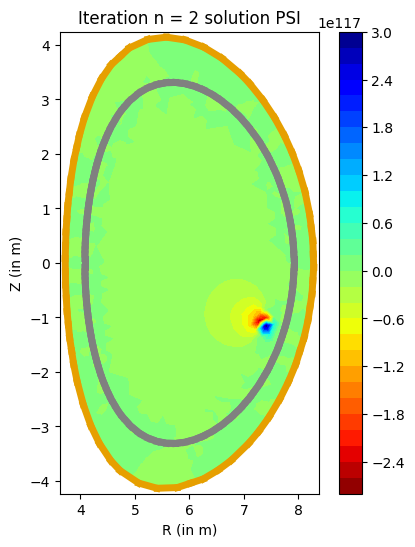

Equilipy --| Internal iteration =  2 , PSI_NORM residu =  1.0
Equilipy --|  
Equilipy --| OUTER ITERATION = 1 , INNER ITERATION = 3
Equilipy --|      Total current =  inf
Equilipy --|      Integrate non-cut elements contributions...

/home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY/TESTs/../src/PlasmaCurrent.py:228: RuntimeWarning: overflow encountered in exp
  -PSI**2+np.exp(-np.sin(Kr*(X[0]+r0))*np.cos(Kz*X[1]))-np.exp(-PSI)))/(X[0]*self.mu0)
/home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY/TESTs/../src/Element.py:1214: RuntimeWarning: invalid value encountered in scalar add
  RHSe[i] += (1/self.Xg[ig,0])*SourceTermg[ig] * self.Nrefg[ig,i] *self.detJg[ig]*self.Wg[ig]
/home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY/TESTs/../src/GradShafranovSolver.py:553: RuntimeWarning: invalid value encountered in add
  self.RHS[ELEMENT.Te[i]] += RHSe[i]


Done!
Equilipy --|      Integrate cut-elements subelements contributions...

/home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY/TESTs/../src/GradShafranovSolver.py:601: RuntimeWarning: invalid value encountered in add
  self.RHS[SUBELEM.Te[i]] += RHSe[i]


Done!
Equilipy --|      Integrate cut-elements interface contributions...Done!
Equilipy --|      Integrate ghost faces contributions...Done!
Equilipy --| Done!


/home/pmanyerfuertes/.pyenv/versions/equilipy-env/lib/python3.12/site-packages/matplotlib/tri/triangulation.py:150: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


ValueError: z array must not contain non-finite values within the triangulation

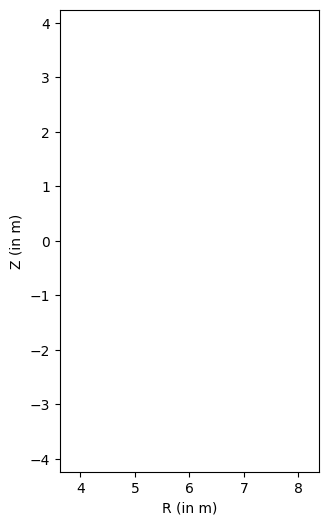

In [41]:
## INITIALISE MESH DATA
Equilibrium.DomainDiscretisation(INITIALISATION = True)
Equilibrium.InitialisePSI()

## NAME SIMULATION CASE 
CASE = "TS-FIXED-NONLINEAR-CutFEM"
## COMPUTE PLASMA EQUILIBRIUM
Equilibrium.EQUILI(CASE)

||PSIerror||_L2 =  0.04205909794545346
relative ||PSIerror||_L2 =  0.07043271317539683
||PSIerror|| =  1.839767817887787
||PSIerror||/node =  0.0011900179934591119
relative ||PSIerror|| =  4.182219239604582


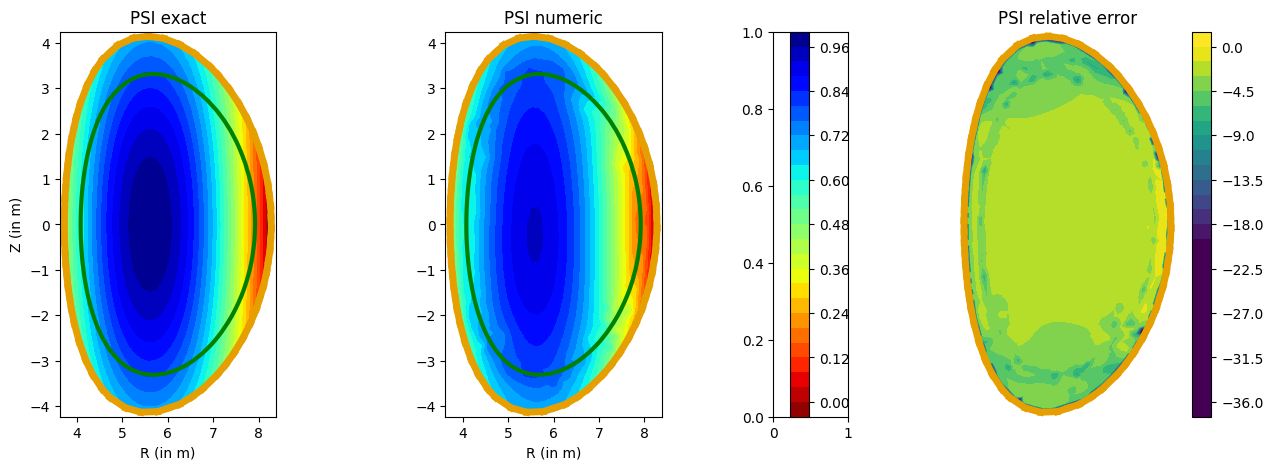

In [ ]:
Equilibrium.PlotError(RelativeError=True)